# Глава 4. SeasonalMovingAverageModel — сезонное скользящее среднее


## 1. Теория

### 1.1 Идея сезонного скользящего среднего

Прогноз — это среднее арифметическое `window` значений ряда, взятых не подряд, а с постоянным шагом `seasonality` назад по времени:

$$\large y_t = \frac{1}{n}\sum_{i=1}^{n} y_{t-i \cdot s}$$

где:
- $y_t$ — прогнозируемое значение в момент времени $t$;
- $n$ — размер окна (`window`) — сколько таких «предыдущих периодов» усредняем;
- $s$ — сезонность (`seasonality`) — шаг в точках между усредняемыми наблюдениями (например, `7` для недельного цикла на дневных данных);
- $y_{t-i \cdot s}$ — значение ровно $i$ периодов назад: факт, если он ещё в пределах истории, или уже собственный прогноз модели (см. раздел 1.3).

Модель усредняет не соседние точки, а «ту же фазу цикла» в прошлом — например, при `seasonality=7` для каждого дня недели берутся именно предыдущие такие же дни недели, а не любые последние `n` дней подряд. Сезонность подбирают под реальный календарный период данных, а не наугад.


### 1.2 Параметры и реализация

Исходник `etna/models/seasonal_ma.py`:

```python
class SeasonalMovingAverageModel(NonPredictionIntervalContextRequiredAbstractModel):
    def __init__(self, window: int = 5, seasonality: int = 7):
        self.window = window
        self.seasonality = seasonality

    @property
    def context_size(self) -> int:
        return self.window * self.seasonality
```

**Параметры `SeasonalMovingAverageModel`:**
- `window` *(int, по умолчанию `5`)* — сколько периодов усредняем.
- `seasonality` *(int, по умолчанию `7`)* — шаг между усредняемыми точками; в докстринге параметра дословно — «лаг между значениями, используемыми для прогноза».
- `context_size = window * seasonality`.

**В отличие от `NaiveModel` и `MovingAverageModel`:** оба параметра свободны одновременно — ни `window`, ни `seasonality` не зафиксированы. Фактически это тот же самый класс, а те два — его частные случаи:
- `NaiveModel(lag=L)` — это `SeasonalMovingAverageModel(window=1, seasonality=L)` (`lag` там был просто `seasonality` под другим именем, `window` жёстко зашит в `1`);
- `MovingAverageModel(window=W)` — это `SeasonalMovingAverageModel(window=W, seasonality=1)`.

Здесь свободны оба — можно усреднять несколько периодов сразу (`window > 1`) и при этом сдвигаться по данным с любым шагом (`seasonality`), а не только на 1 назад.


### 1.3 Особенности

- **`seasonality` — это тот же `lag`, что был у `NaiveModel`, просто под родным именем.** У `NaiveModel` не было собственной формулы — это был тот же класс с `window=1`, а его `lag` передавался родителю как `seasonality`. Поэтому золотое правило переносится сюда дословно: `seasonality ≥ horizon` защищает от рекурсии — прогноз строится только по фактам. У `MovingAverageModel` это было структурно невозможно (`seasonality` жёстко `=1`) — здесь контроль снова полностью в твоих руках.
- **Неправильный `seasonality` ломает прогноз вне зависимости от `window`.** В отличие от `window` (тот просто регулирует силу сглаживания), `seasonality`, не совпадающая с реальной цикличностью ряда, заставляет модель усреднять несвязанные между собой точки — например, понедельник с четвергом, если реальный период — неделя, а `seasonality` этому не кратна. Увидишь это на синтетике в Задании 1.
- **`seasonality`, кратная истинному периоду, тоже работает.** Например, если реальный период — 7 дней, то `seasonality=14` или `seasonality=21` тоже попадают в ту же фазу (тот же день недели), просто заглядывают на цикл дальше назад.


## 2. Данные

Те же файлы, что и в предыдущих тетрадях (`local/data/`, в `.gitignore`):
- `units.csv` — 10 юнитов; для основной практики берём 2 из них (размер `10+`, typical + busier), для бонуса — все 10.
- `facts-by-date.csv` — дневные факты, 2022-01-01…2026-08-31.
- `facts-by-hour.csv` — почасовая гранулярность, если захочешь заглянуть вперёд.

В этой главе не сравниваем с продовым прогнозом (`forecasts-by-date.csv`) — это отдельная тема, которой займёшься сам.


In [7]:
import numpy as np
import pandas as pd

from etna.datasets import TSDataset, generate_periodic_df
from etna.models import SeasonalMovingAverageModel, MovingAverageModel, NaiveModel
from etna.metrics import SMAPE, WAPE, MAPE, MAE
from etna.analysis import plot_forecast

from src.custom_logger import log_to_mlflow
from src.prod_metrics import bias, pooled

DATA_DIR = "../../local/data"


## 3. Практика


### Задание 1. Синтетика: `seasonality` должен попасть в реальный период данных

1. Сгенерируй периодический синтетический ряд через `generate_periodic_df` (`period=7`, без шума) — в отличие от чистого тренда в прошлой главе, для периодичности в ETNA как раз есть готовый генератор.
2. Выбери `HORIZON` и раздели ряд на train/test.
3. Обучи `SeasonalMovingAverageModel(window=1, seasonality=7)` (совпадает с реальным периодом) и `SeasonalMovingAverageModel(window=1, seasonality=3)` (не совпадает) — сравни прогнозы визуально через `plot_forecast`.
4. Вопросы:
    - какой `seasonality` дал точный прогноз и почему?
    - что модель в итоге усредняет при «неправильном» `seasonality` — почему получается бессмыслица, а не просто «чуть хуже»?
5. Доп. (задел на золотое правило): возьми `seasonality=7` (правильный период), но `horizon=14` (две недели) — сравни первую и вторую неделю прогноза. Помнишь правило `lag ≥ horizon` у `NaiveModel`? Здесь то же самое, только `lag` теперь называется `seasonality`.


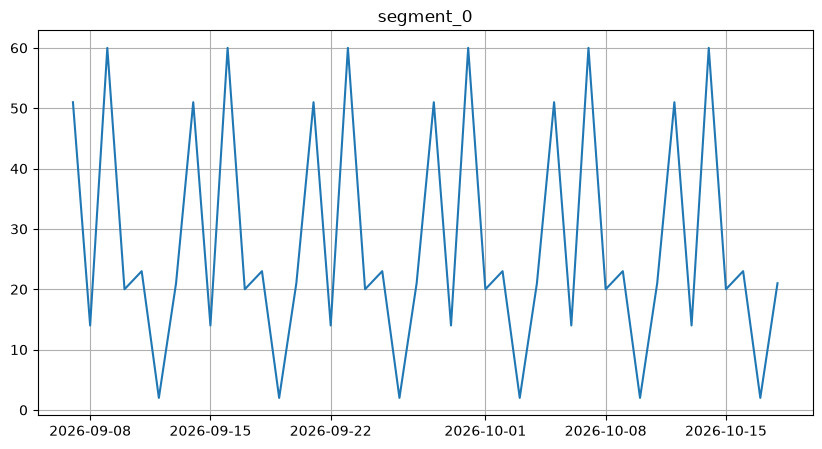

In [8]:
df = generate_periodic_df(
    periods=42,
    start_time="2026-09-07",
    scale=67,
    period=7,
    n_segments=1,
    freq="D",
    add_noise=False,
    sigma=0,
    random_seed=42,
)

ts = TSDataset(df, freq="D")
ts.plot()

In [9]:
def get_forecast(data, horizon, window, seasonality, n_train_samples=None, is_log=True):

    train_ts, test_ts = data.train_test_split(test_size=horizon)
    model = SeasonalMovingAverageModel(window=window, seasonality=seasonality)
    model.fit(train_ts)
    future_ts = train_ts.make_future(future_steps=horizon, tail_steps=model.context_size)
    forecast_ts = model.forecast(ts=future_ts, prediction_size=horizon)

    if is_log:
        plot_forecast(forecast_ts=forecast_ts, train_ts=train_ts, test_ts=test_ts, n_train_samples=n_train_samples)

    return train_ts, test_ts, forecast_ts


{'segment_0': 0.0}

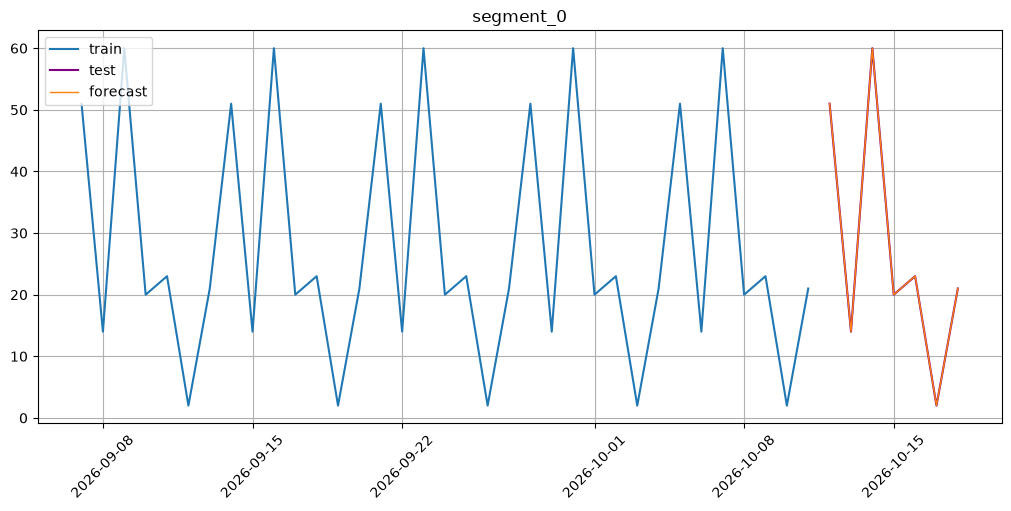

In [10]:
train_ts, test_ts, forecast_ts = get_forecast(data=ts, horizon=7, window=1, seasonality=7)
SMAPE()(y_true=test_ts, y_pred=forecast_ts)

{'segment_0': 96.89053724847456}

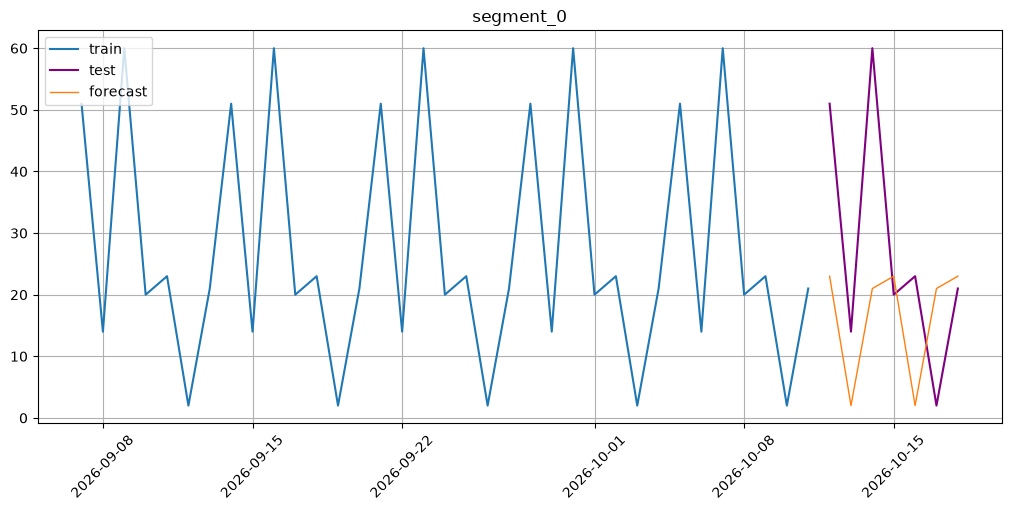

In [11]:
train_ts, test_ts, forecast_ts = get_forecast(data=ts, horizon=7, window=1, seasonality=3)
SMAPE()(y_true=test_ts, y_pred=forecast_ts)


**Какой `seasonality` дал точный прогноз и почему?**

На `seasonality=7` SMAPE = 0, а на `seasonality=3` SMAPE ≈ 97.
- При `seasonality=7` для прогноза понедельника модель берёт значения прошлых понедельников — сохраняется недельный ритм. Ожидается, что понедельник похож на понедельник больше, чем на пятницу.
- При `seasonality=3` для прогноза понедельника берётся значение 3 дня назад (пятница). Происходит рассинхрон и это дает рост ошибки.

**Что модель усредняет при «неправильном» `seasonality` — почему бессмыслица, а не «чуть хуже»?**
- Она усредняет не те дни недели, которые нужно предсказать. Понедельники прогнозируются по пятницам, вторники по субботам, ... . Раз реальный ряд имеет недельную структуру, а модель систематически смотрит не в ту фазу цикла, ошибка получается не случайной, а систематической. Это дает последовательное несовпадение с реальным паттерном.

Без шума
Неделя 1: [51. 14. 60. 20. 23.  2. 21.]
Неделя 2: [51. 14. 60. 20. 23.  2. 21.]
Неделя 1 == Неделя 2: True
SMAPE: {'segment_0': 0.0}

С шумом
Неделя 1: [49.87 14.34 52.88 17.28 23.55 -3.75 22.88]
Неделя 2: [49.87 14.34 52.88 17.28 23.55 -3.75 22.88]
Неделя 1 == Неделя 2: True
SMAPE: {'segment_0': 25.276644221334347}


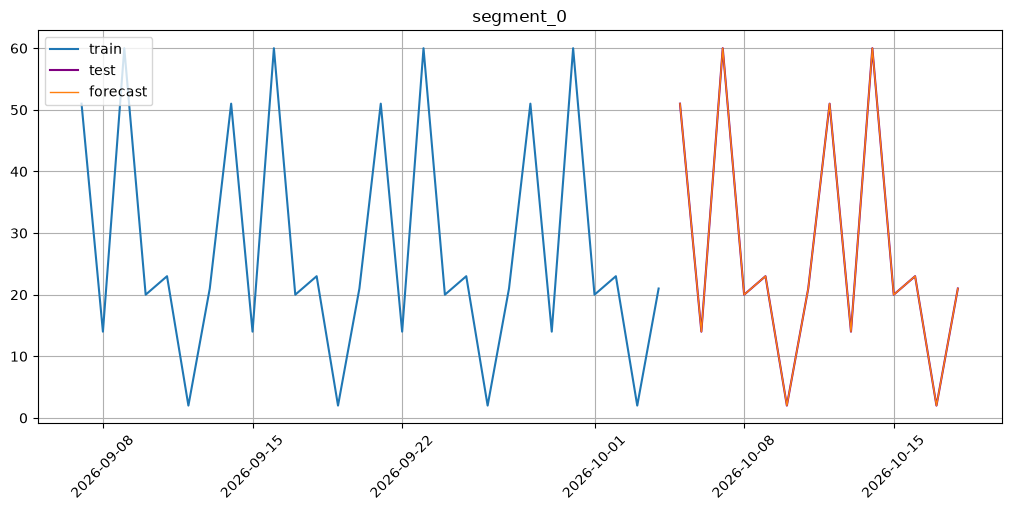

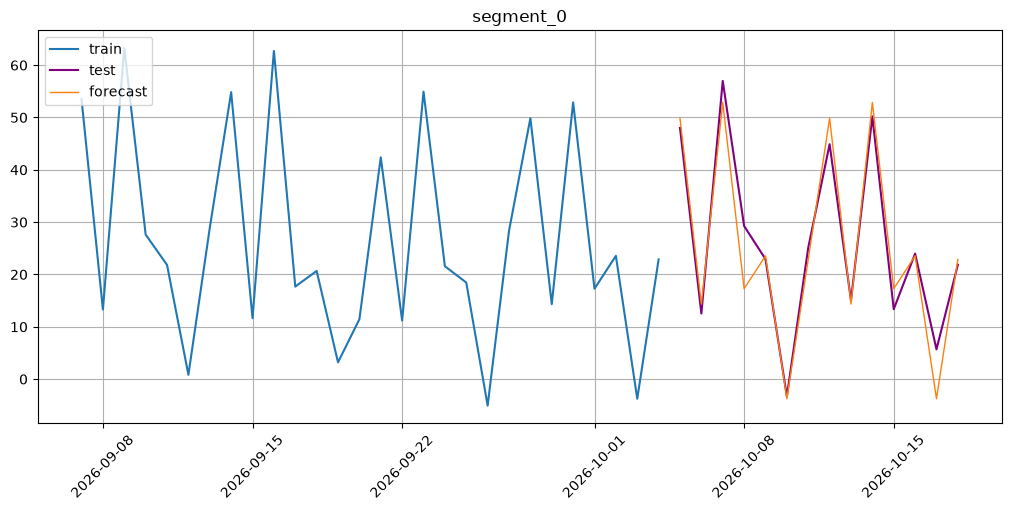

In [12]:
	# Золотое правило `lag ≥ horizon` -> `seasonality ≥ horizon`.
# Проверяем нарушение правила (seasonality=7 < horizon=14) сразу в двух вариантах: без шума и с шумом.

# Без шума
train_ts, test_ts, forecast_ts = get_forecast(data=ts, horizon=14, window=1, seasonality=7)
forecast_values = forecast_ts[:, :, "target"].values.flatten()
week_1, week_2 = forecast_values[:7], forecast_values[7:]

print("Без шума")
print("Неделя 1:", np.round(week_1, 2))
print("Неделя 2:", np.round(week_2, 2))
print("Неделя 1 == Неделя 2:", np.allclose(week_1, week_2))
print("SMAPE:", SMAPE()(y_true=test_ts, y_pred=forecast_ts))

# С шумом
df_noisy = generate_periodic_df(
    periods=42,
    start_time="2026-09-07",
    scale=67,
    period=7,
    n_segments=1,
    freq="D",
    add_noise=True,
    sigma=5,
    random_seed=42,
)
ts_noisy = TSDataset(df_noisy, freq="D")

train_ts_n, test_ts_n, forecast_ts_n = get_forecast(data=ts_noisy, horizon=14, window=1, seasonality=7)
forecast_values_n = forecast_ts_n[:, :, "target"].values.flatten()
week_1_n, week_2_n = forecast_values_n[:7], forecast_values_n[7:]

print("\nС шумом")
print("Неделя 1:", np.round(week_1_n, 2))
print("Неделя 2:", np.round(week_2_n, 2))
print("Неделя 1 == Неделя 2:", np.allclose(week_1_n, week_2_n))
print("SMAPE:", SMAPE()(y_true=test_ts_n, y_pred=forecast_ts_n))

**Золотое правило `seasonality ≥ horizon`:**
- Если `seasonality < horizon`, то модель начинает предсказывать по своим же прогнозам, а не по фактам. В нашем примере вторая неделя - копия первой. И не важно, есть шум в данных или нет.
- Без шума скопированное значение и так было точным, поэтому `SMAPE=0` - подмена фактов прогнозом незаметна. С шумом копируется уже неточное значение, и эта неточность просто повторяется на весь оставшийся горизонт без изменений. Это и дает `SMAPE ≈ 25`.


### Задание 2. Загрузи данные по 2 юнитам размера `10+`

1. Прочитай `facts-by-date.csv` и `units.csv`, оставь только 2 юнита размера `10+` (typical + busier) — так же, как для предыдущих моделей.
2. Собери `TSDataset` (дневная частота), где `segment` = `MaskedUnitId`.
3. Посмотри на `ts.describe()`.
4. Построй `ts.plot()`.


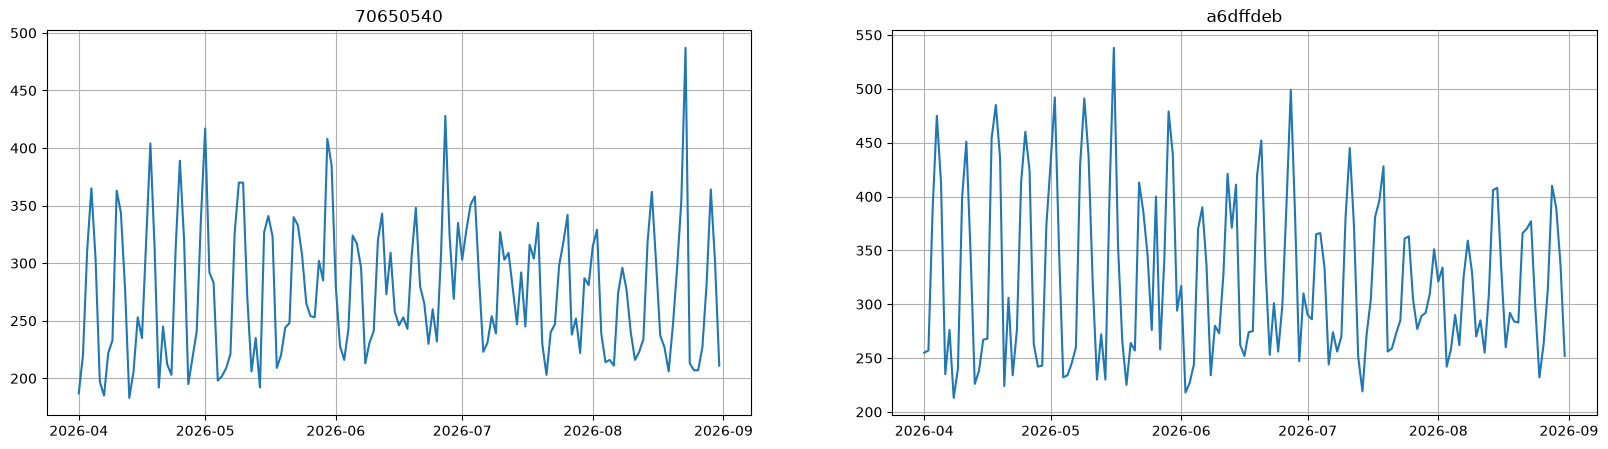

In [13]:
units_df = (pd
.read_csv(filepath_or_buffer=f"{DATA_DIR}/units.csv")
.rename(columns={
    "MaskedUnitId": "segment",
    "UnitSize": "unit_size",
    "PickReason": "pick_reason",
    "TotalOrders":"total_orders"
})
[["segment", "unit_size", "pick_reason", "total_orders"]]

)

orders_df = (
    pd.read_csv(f"{DATA_DIR}/facts-by-date.csv")
    .rename(columns={
        "CalendarDate": "timestamp",
        "MaskedUnitId": "segment",
        "Fact": "target",
    })
    [["timestamp", "segment", "target"]]
)

# Грязно выравниваем дату начала ряда, чтобы данные были по всем юнитам
orders_df = orders_df[orders_df['timestamp'] >= "2026-04-01"]
# Отбираем юниты
orders_sample_df = orders_df.merge(units_df[units_df["unit_size"] == "10+"]["segment"], how="inner", left_on="segment", right_on="segment", copy=True)

orders_sample_ts = TSDataset(orders_sample_df, freq="D")
orders_sample_ts.plot()

### Задание 3. Подбираем `seasonality` на одном юните

Возьми один юнит (например, самый «busier» из размера `10+`).

1. Выбери `HORIZON` (например, 14 дней) и раздели ряд на train/test.
2. Обучи `SeasonalMovingAverageModel` для нескольких `seasonality` при фиксированном `window` (например, `window=3`): `seasonality=1`, `seasonality=3`, `seasonality=7`, `seasonality=14`.
3. Посчитай `SMAPE` для каждого варианта и визуализируй через `plot_forecast` (можно все сразу, словарём).
4. Какой `seasonality` выглядит осмысленным для дневных данных о заказах? Совпадает ли твоя интуиция с тем, что показывает метрика?


,a6dffdeb
seasonality,
14,6.224377
7,6.621286
1,15.073760
3,15.141120


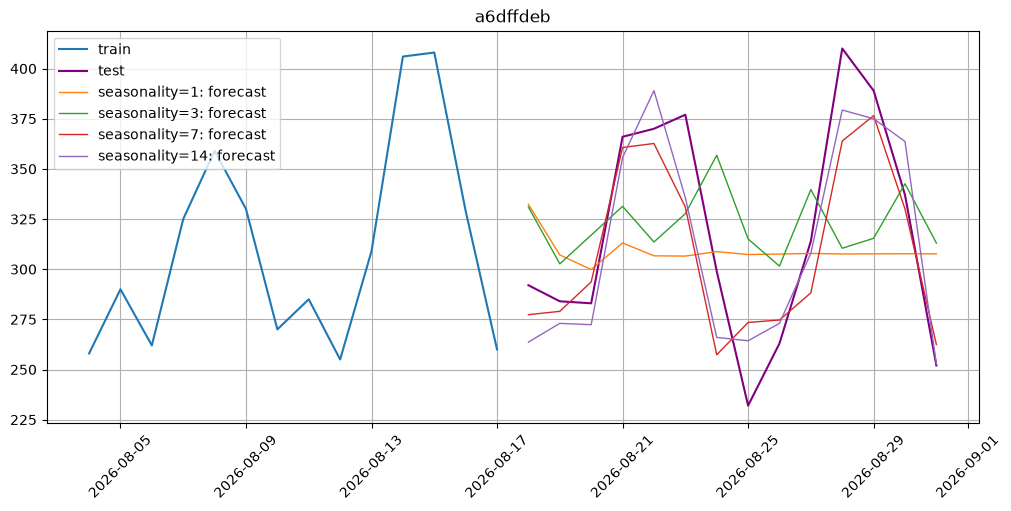

In [14]:
orders_one_ts = TSDataset(df=orders_sample_ts[:, "a6dffdeb", :], freq=orders_sample_ts.freq)

records = []
forecasts_by_seasonality = {}

for seasonality in [1, 3, 7, 14]:
    train_ts, test_ts, forecast_ts = get_forecast(
        data=orders_one_ts, horizon=14, window=3, seasonality=seasonality, is_log=False
    )
    smape_per_segment = SMAPE()(y_true=test_ts, y_pred=forecast_ts)
    records.append({"seasonality": seasonality, **smape_per_segment})
    forecasts_by_seasonality[f"seasonality={seasonality}"] = forecast_ts

results_df = pd.DataFrame(records).set_index("seasonality")
display(results_df.sort_values("a6dffdeb"))

# train_ts/test_ts одинаковые на каждой итерации (меняется только seasonality) — последние из цикла
plot_forecast(forecast_ts=forecasts_by_seasonality, test_ts=test_ts, train_ts=train_ts, n_train_samples=14)

### Задание 4. Общая картина по обоим юнитам — выбираем `window`/`seasonality`

1. Обучи `SeasonalMovingAverageModel` сразу на обоих сегментах для нескольких сочетаний `window`/`seasonality`.
2. Посчитай `SMAPE` — per-segment и агрегированно (`mode="macro"`).
3. Сравни — какое сочетание даёт наименьшую агрегированную ошибку? Оправдало ли себя добавление `seasonality` по сравнению с лучшим `window` из `MovingAverageModel`?


smape_agg   70650540  a6dffdeb
window seasonality                                
1      7             8.243267   8.906116  7.580419
       14            9.093710  11.258364  6.929057
3      7             7.554388   8.487489  6.621286
       14            9.573505  12.922633  6.224377
5      7             8.205685   9.714026  6.697343
       14            9.669462  13.547658  5.791265

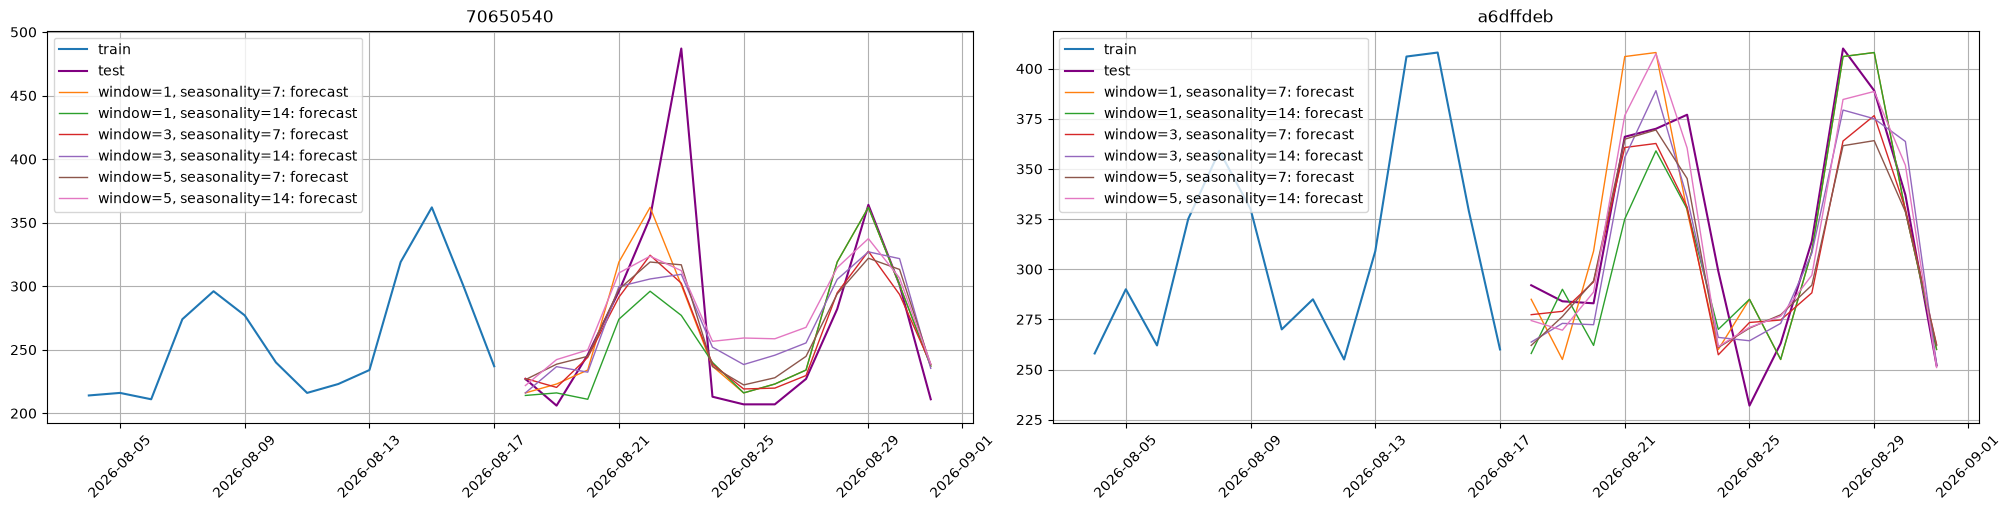

In [15]:
records = []
forecasts_by_combo = {}

for window in [1, 3, 5]:
    for seasonality in [7, 14]:
        train_ts, test_ts, forecast_ts = get_forecast(
            data=orders_sample_ts, horizon=14, window=window, seasonality=seasonality, is_log=False
        )
        smape_per_segment = SMAPE()(y_true=test_ts, y_pred=forecast_ts)
        smape_agg = SMAPE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
        records.append({"window": window, "seasonality": seasonality, "smape_agg": smape_agg, **smape_per_segment})
        forecasts_by_combo[f"window={window}, seasonality={seasonality}"] = forecast_ts

results_df = pd.DataFrame(records).set_index(["window", "seasonality"])
display(results_df.sort_index())

# train_ts/test_ts одинаковые на каждой итерации — последние из цикла
plot_forecast(forecast_ts=forecasts_by_combo, test_ts=test_ts, train_ts=train_ts, n_train_samples=14)

### Бонус. Общая картина по всем 10 юнитам + логирование

1. Прогони лучшее сочетание `window`/`seasonality` сразу на всех 10 юнитах (используй `orders_df` из Задания 2 без фильтра по `unit_size`).
2. Посчитай весь набор метрик — `SMAPE`, `WAPE`, `MAPE`, `MAE`, `Bias` (через `src/prod_metrics.py`), per-segment и агрегированно.
3. Собери всё в одну таблицу `result` (`segment`/`unit_size`/`pick_reason`/`total_orders` + все метрики).
4. Залогируй через `log_to_mlflow(...)`, не забудь `tags={"chapter": "ch04", "units_scope": "all_10", "granularity": "day"}` — тогда в MLflow сможешь сравнить со всеми предыдущими моделями прямо в таблице запусков.


In [16]:
# "Лучшее" сочетание по итогам Задания 4
BEST_WINDOW = 3
BEST_SEASONALITY = 7
HORIZON = 14

# Все 10 юнитов сразу
orders_ts = TSDataset(orders_df, freq="D")

train_ts, test_ts, forecast_ts = get_forecast(
    data=orders_ts, horizon=HORIZON, window=BEST_WINDOW, seasonality=BEST_SEASONALITY, is_log=False
)

# Метрики
smape_per_segment = SMAPE()(y_true=test_ts, y_pred=forecast_ts)
wape_per_segment = WAPE()(y_true=test_ts, y_pred=forecast_ts)
mape_per_segment = MAPE()(y_true=test_ts, y_pred=forecast_ts)
mae_per_segment = MAE()(y_true=test_ts, y_pred=forecast_ts)
bias_per_segment = bias(y_true=test_ts, y_pred=forecast_ts)

# Агрегаты по всей выборке
smape_agg = SMAPE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
mape_agg = MAPE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
mae_agg = MAE(mode="macro")(y_true=test_ts, y_pred=forecast_ts)
wape_agg = pooled(test_ts, forecast_ts, signed=False)
bias_agg = pooled(test_ts, forecast_ts, signed=True)

print(f"SMAPE (macro):  {smape_agg:.2f}")
print(f"MAPE  (macro):  {mape_agg:.2f}")
print(f"MAE   (macro):  {mae_agg:.2f}")
print(f"WAPE  (pooled): {wape_agg:.2f}")
print(f"Bias  (pooled): {bias_agg:+.2f}")

# Всё — в одну таблицу по каждому юниту
result = units_df.copy()
result["smape"] = result["segment"].map(smape_per_segment)
result["wape"] = result["segment"].map(wape_per_segment)
result["mape"] = result["segment"].map(mape_per_segment)
result["mae"] = result["segment"].map(mae_per_segment)
result["bias"] = result["segment"].map(bias_per_segment)
result.sort_values("smape")

SMAPE (macro):  11.72
MAPE  (macro):  14.50
MAE   (macro):  15.14
WAPE  (pooled): 9.79
Bias  (pooled): -3.23


,segment,unit_size,pick_reason,total_orders,smape,wape,mape,mae,bias
5,733e17e8,5–7,typical (p25),12470,6.381508,0.064227,6.440328,8.523810,-0.705657
0,a6dffdeb,10+,busier (p75),29099,6.621286,0.063911,6.521827,20.396825,-3.068736
1,70650540,10+,typical (p25),25437,8.487489,0.097527,7.941854,26.666667,-4.098456
6,aa88e1ec,7–10,busier (p75),19363,8.543815,0.084994,8.689277,16.452381,0.061501
3,9bb64107,3–5,typical (p25),7888,8.661002,0.083617,8.365436,7.023810,-4.639078
2,3bfb39ef,3–5,busier (p75),9530,11.014582,0.114074,10.870835,12.222222,-2.474074
7,d3319417,7–10,typical (p25),17464,12.074453,0.121223,11.613016,23.214286,-8.218326
4,155082de,5–7,busier (p75),13509,12.804268,0.120894,11.771821,18.634921,-11.749562
8,8a399130,<3,busier (p75),5646,18.652431,0.193063,21.191175,9.984127,13.198281
9,a5cd0472,<3,typical (p25),4051,23.942653,0.209209,51.601499,8.293651,13.713714


In [17]:
# Логируем — сравнить с NaiveModel/MovingAverageModel можно прямо в таблице запусков MLflow.
log_to_mlflow(
    model_name="SeasonalMovingAverageModel",
    model_params={"window": BEST_WINDOW, "seasonality": BEST_SEASONALITY, "horizon": HORIZON},
    metrics={
        "smape_macro": smape_agg,
        "mape_macro": mape_agg,
        "mae_macro": mae_agg,
        "wape_pooled": wape_agg,
        "bias_pooled": bias_agg,
    },
    metrics_per_segment={
        "smape": smape_per_segment,
        "wape": wape_per_segment,
        "mape": mape_per_segment,
        "mae": mae_per_segment,
        "bias": bias_per_segment,
    },
    segment_table=result,
    tags={"chapter": "ch04", "units_scope": "all_10", "granularity": "day"},
    run_name_suffix="ch04_all_10_day",
)
